In [1]:
import numpy as np
import matplotlib.pyplot as plt
import wgsceria as m

In [2]:
# Boundary conditions
T = np.arange(800, 1110, 10)    # K
PCO  = 0.34  # bar
PH2O = 0.64  # bar
PCO2 = 0.01  # bar
PH2  = 0.01  # bar

In [3]:
# Seed
theta0 = np.zeros(13)
theta0[11] = 1.0   # empty Ce
theta0[12] = 1.0   # empty O

In [7]:
theta_all = []
rates_all = []
K_all = []
kf_all = []
theta_prev = theta0

for Ti in T:
    K, kf, kr = m.get_k(Ti, [PCO, PH2O, PCO2, PH2])
    K_all.append(K)
    kf_all.append(kf)

    theta = m.int_conv(kf, kr, theta_prev)
    
    theta_all.append(theta)
    theta_prev = theta

    #rates = m.get_rates(theta, kf, kr)
    #rates_all.append(rates)

theta_all = np.array(theta_all)
K_all = np.array(K_all)
kf_all = np.array(kf_all)

In [11]:
# Calculate DRC for selected steps
drc_6 = [] # H2 formation from OH (R6)
drc_13 = [] # Formate formation (R13)
drc_14 = [] # Formate dehydrogenation (R14)

for i, Ti in enumerate(T):
    drc_6.append(m.get_drc(K_all[i], kf_all[i], theta_all[i,:], 5))
    drc_13.append(m.get_drc(K_all[i], kf_all[i], theta_all[i,:], 12))
    drc_14.append(m.get_drc(K_all[i], kf_all[i], theta_all[i,:], 13))

drc_6 = np.array(drc_6)
drc_13 = np.array(drc_13)
drc_14 = np.array(drc_14)

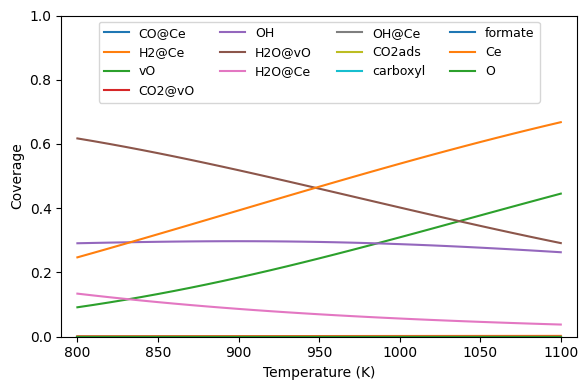

In [ ]:
labels = [
    'CO@Ce', 'H2@Ce', 'vO', 'CO2@vO', 'OH',
    'H2O@vO', 'H2O@Ce', 'OH@Ce', 'CO2ads',
    'carboxyl', 'formate', 'Ce', 'O'
]

fig, ax = plt.subplots(figsize=(6,4))

for i, label in enumerate(labels):
    ax.plot(T, theta_all[:, i], label=label)

ax.set_xlabel('Temperature (K)')
ax.set_ylabel('Coverage')
ax.set_xlim(790, 1110)
ax.set_ylim(0, 1)
ax.legend(ncol=4, fontsize=9, loc='upper center')
#ax.grid(True)

fig.tight_layout()
fig.savefig('figures/T_coverage.png', dpi=300)
plt.show()

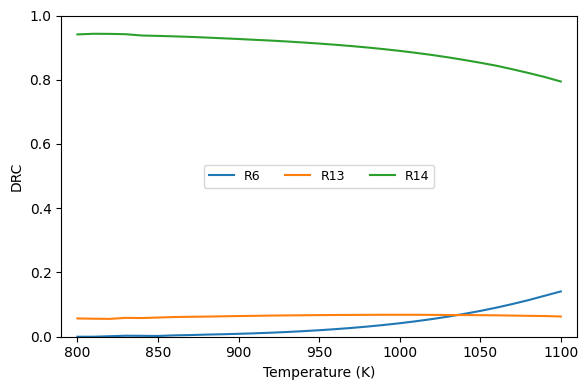

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))

ax.plot(T, drc_6, label='R6')
ax.plot(T, drc_13, label='R13')
ax.plot(T, drc_14, label='R14')

ax.set_xlabel('Temperature (K)')
ax.set_ylabel('DRC')
ax.set_xlim(790, 1110)
ax.set_ylim(0, 1)
ax.legend(ncol=4, fontsize=9, loc='center')
#ax.grid(True)

fig.tight_layout()
fig.savefig('figures/T_DRC.png', dpi=300)
plt.show()